In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import skew, kurtosis, shapiro
import warnings
import pmdarima as pm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.stats.diagnostic as diag
import statsmodels.stats.proportion as prop
from datetime import datetime

# Ignore common warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7) # Larger default figure size
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [16]:
# --- Step 1.1: Load & Verify Prep ---
# Load the dataset
file_path_filled = 'DC_Master_Data_Filled.csv'
df_filled = pd.read_csv(file_path_filled)

# Convert 'Date' column to datetime objects
df_filled['Date'] = pd.to_datetime(df_filled['Date'])

# Set 'Date' as the index
df_filled.set_index('Date', inplace=True)

In [17]:
# --- Step 1.2: Basic Information ---
print("\n--- Basic Information ---")
print(f"Shape of the DataFrame: {df_filled.shape}")
time_period = df_filled.index.max() - df_filled.index.min()
print(f"Time period covered: {df_filled.index.min().strftime('%Y-%m-%d')} to {df_filled.index.max().strftime('%Y-%m-%d')}")
print(f"Duration: {time_period.days} days")


--- Basic Information ---
Shape of the DataFrame: (140, 9)
Time period covered: 1990-01-01 to 2024-10-01
Duration: 12692 days


In [18]:
# --- Step 1.3: Descriptive Statistics ---
print("\n--- Descriptive Statistics ---")
desc_stats = df_filled.describe().T
# Calculate IQR
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
# Calculate Coefficient of Variation (CV) = std / mean
desc_stats['CV'] = (desc_stats['std'] / desc_stats['mean']).abs()
# Calculate Skewness and Kurtosis
desc_stats['Skewness'] = df_filled.apply(skew)
desc_stats['Kurtosis'] = df_filled.apply(kurtosis) # Fisher’s definition (normal=0)
print(desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'CV', 'Skewness', 'Kurtosis']])


--- Descriptive Statistics ---
                         count          mean           std           min  \
House_Index              140.0    205.550357     85.940726    100.000000   
CPI                      140.0    213.331111     50.484224    132.000000   
Poverty_Rate             140.0     12.980000      1.344243     10.500000   
Unemployment_Rate        140.0      5.711429      1.440278      2.600000   
Median_Household_Income  140.0  77782.821429  18003.414039  53450.000000   
Population               140.0   5363.002787    745.377352   4088.514122   
Interest_Rate            140.0      2.844429      2.381055      0.050000   
Mortgage_Rate            140.0      6.004671      1.880658      2.735000   
GDP                      140.0  14572.347771   6301.461511   5872.701000   

                                  25%           50%           75%  \
House_Index                107.165000    214.405000    266.237500   
CPI                        164.887500    216.237000    252.326375   


In [19]:
# --- Step 1.4: Outlier Detection (IQR Method) ---
print("\n--- Outlier Detection (IQR Method) ---")
outliers_summary = {}
for column in df_filled.columns:
    Q1 = df_filled[column].quantile(0.25)
    Q3 = df_filled[column].quantile(0.75)
    IQR_val = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR_val
    upper_bound = Q3 + 1.5 * IQR_val

    # Identify outliers
    outliers = df_filled[(df_filled[column] < lower_bound) | (df_filled[column] > upper_bound)]
    if not outliers.empty:
        outliers_summary[column] = {
            'count': len(outliers),
            'indices': outliers.index.strftime('%Y-%m-%d').tolist(),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        print(f"Potential outliers found in '{column}': {len(outliers)}")
        # print(f"  Indices: {outliers.index.strftime('%Y-%m-%d').tolist()}")
        # print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print(f"No potential outliers found in '{column}' based on IQR.")
        outliers_summary[column] = {'count': 0}


--- Outlier Detection (IQR Method) ---
No potential outliers found in 'House_Index' based on IQR.
No potential outliers found in 'CPI' based on IQR.
No potential outliers found in 'Poverty_Rate' based on IQR.
Potential outliers found in 'Unemployment_Rate': 2
No potential outliers found in 'Median_Household_Income' based on IQR.
No potential outliers found in 'Population' based on IQR.
No potential outliers found in 'Interest_Rate' based on IQR.
No potential outliers found in 'Mortgage_Rate' based on IQR.
No potential outliers found in 'GDP' based on IQR.


In [20]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['House_Index']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")

# --- Continue with your next steps ---


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=728.863, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=833.530, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=717.487, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=733.118, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=855.811, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=752.226, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=719.253, Time=0.05 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=719.305, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=727.060, Time=0.03 sec
 ARIMA(1,1,0)(2,0,1)[4] intercept   : AIC=721.106, Time=0.09 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=775.009, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[4] intercept   : AIC=719.402, Time=0.04 sec
 ARIMA(1,1,1)(1,0,0)[4] intercept   : AIC=719.283, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[4] intercept   : AIC=724.933, Time=0.03 sec
 ARIMA(2,1,1)(1,0,0

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 2: Define and Fit the SARIMA Model ---
# Model parameters identified by auto_arima
order = (3, 1, 2)
seasonal_order = (1, 0, 0, 4)

print(f"Fitting SARIMA{order}x{seasonal_order} model...")

# Define the model using statsmodels
# trend='c' includes a constant intercept, similar to auto_arima's behavior
model = SARIMAX(house_index_series,
                order=order,
                seasonal_order=seasonal_order,
                trend='c',
                enforce_stationarity=False, # Often needed for higher orders
                enforce_invertibility=False) # Often needed for higher orders

# Fit the model
results = model.fit(disp=False) # disp=False hides convergence output
print("Model fitting complete.")
# Optional: print summary to check coefficients if desired
# print(results.summary())

# --- Step 3: Generate Forecasts ---
# Forecast 3 steps ahead for 2025-01-01, 2025-04-01, 2025-07-01
n_steps = 3
print(f"Generating {n_steps}-step ahead forecast...")
forecast_object = results.get_forecast(steps=n_steps)

# Extract point forecasts
point_forecasts = forecast_object.predicted_mean

# Extract confidence intervals (optional)
conf_int = forecast_object.conf_int(alpha=0.05) # 95% confidence interval

# Combine forecasts and confidence intervals into a DataFrame for nice display
forecast_df = pd.DataFrame({
    'Forecast': point_forecasts,
    'Lower 95% CI': conf_int.iloc[:, 0],
    'Upper 95% CI': conf_int.iloc[:, 1]
})

# --- Step 4: Display Forecasts ---
print("\n--- Baseline SARIMA Forecasts for House_Index ---")
print(forecast_df)

Fitting SARIMA(3, 1, 2)x(1, 0, 0, 4) model...
Model fitting complete.
Generating 3-step ahead forecast...

--- Baseline SARIMA Forecasts for House_Index ---
              Forecast  Lower 95% CI  Upper 95% CI
2025-01-01  398.777236    392.859979    404.694493
2025-04-01  408.437083    397.238115    419.636052
2025-07-01  409.477240    393.816292    425.138188


Performing 1-step ahead rolling forecast...
Forecasting for: 2023-01-01
Forecasting for: 2023-04-01
Forecasting for: 2023-07-01
Forecasting for: 2023-10-01
Forecasting for: 2024-01-01
Forecasting for: 2024-04-01
Forecasting for: 2024-07-01
Forecasting for: 2024-10-01

--- 1-Step Ahead Forecast Evaluation Metrics ---
Mean Absolute Error (MAE):       3.865
Root Mean Squared Error (RMSE):  4.842
Mean Absolute Percentage Error (MAPE): 0.010
Performing 2-step ahead rolling forecast...
Forecasting for: 2023-01-01
Forecasting for: 2023-04-01
Forecasting for: 2023-07-01
Forecasting for: 2023-10-01
Forecasting for: 2024-01-01
Forecasting for: 2024-04-01
Forecasting for: 2024-07-01

--- 2-Step Ahead Forecast Evaluation Metrics ---
Mean Absolute Error (MAE):       6.989
Root Mean Squared Error (RMSE):  8.988
Mean Absolute Percentage Error (MAPE): 0.018

--- Comparison of 1-step vs 2-step Forecasting ---
        1-Step    2-Step
MAE   3.864899  6.989438
RMSE  4.841773  8.987858
MAPE  0.010240  0.0

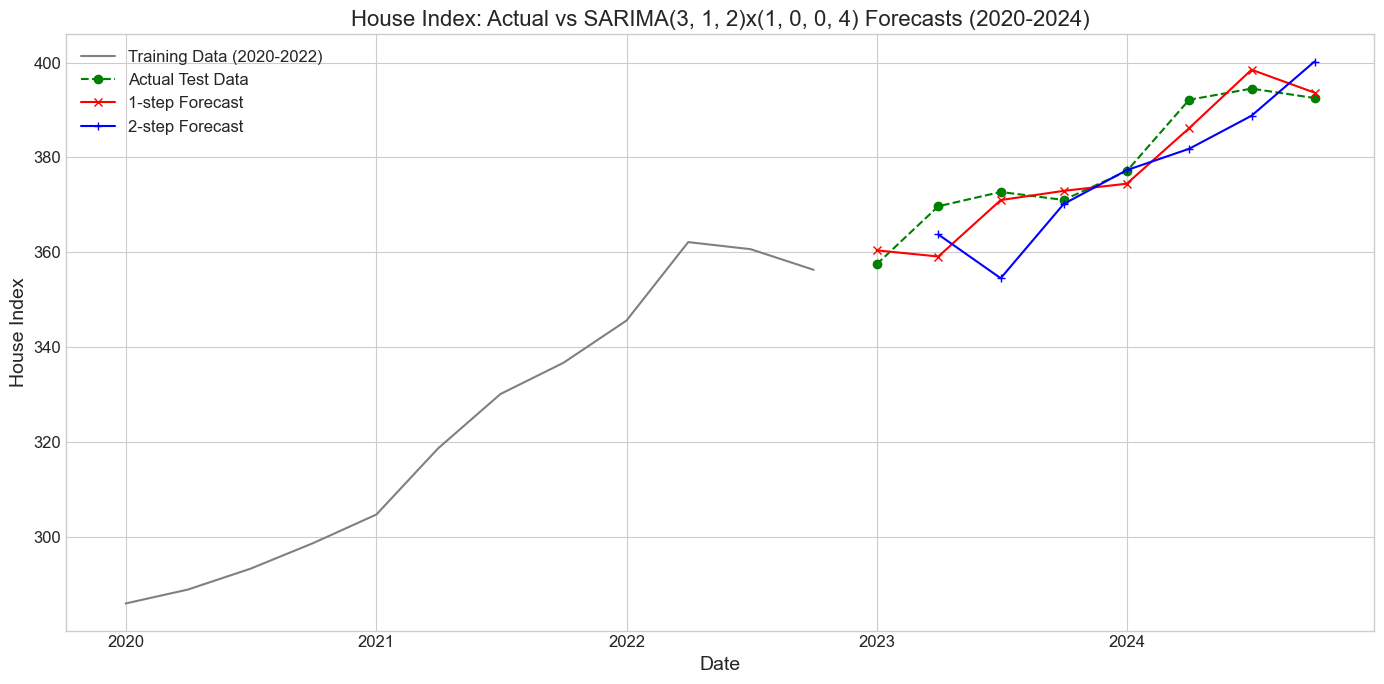

<Figure size 1000x600 with 0 Axes>

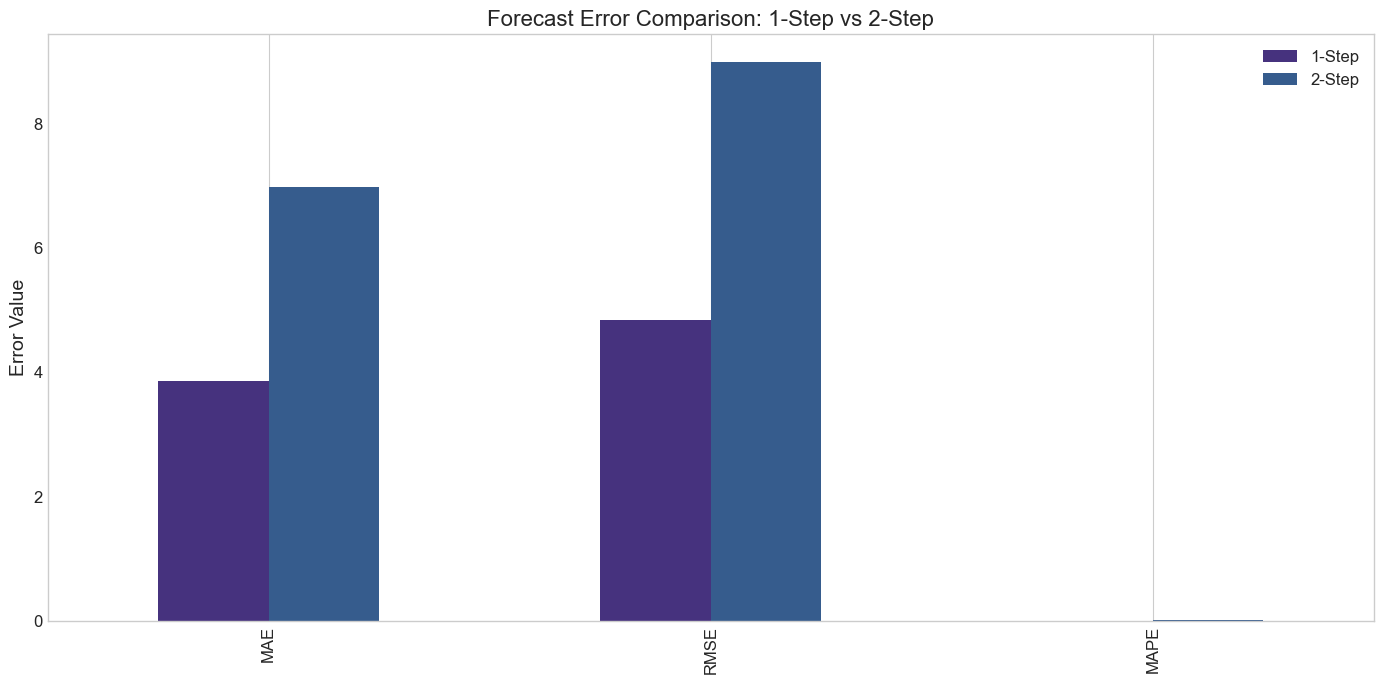

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# Suppress convergence and other warnings for cleaner output
warnings.filterwarnings("ignore")

# Load Data
house_index_series = df_filled['House_Index']

# Define test period and model parameters
test_start_date = '2023-01-01'
test_series = house_index_series[house_index_series.index >= test_start_date]
model_order = (3, 1, 2)
seasonal_order = (1, 0, 0, 4)
trend = 'c'

# Function to perform rolling forecast
def perform_rolling_forecast(steps_ahead):
    history = house_index_series[house_index_series.index < test_start_date].copy()
    predictions = []
    actuals = []
    
    print(f"Performing {steps_ahead}-step ahead rolling forecast...")
    
    # For 1-step, we can use all test dates; for 2-step, we need to skip the last one
    forecast_dates = test_series.index[:-steps_ahead+1] if steps_ahead > 1 else test_series.index
    
    for t, current_date in enumerate(forecast_dates):
        print(f"Forecasting for: {current_date.strftime('%Y-%m-%d')}")
        
        # Define and fit model
        model = SARIMAX(
            history,
            order=model_order,
            seasonal_order=seasonal_order,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        
        # Get forecast
        forecast_object = results.get_forecast(steps=steps_ahead)
        yhat = forecast_object.predicted_mean.iloc[steps_ahead-1]  # Get the n-step ahead forecast
        predictions.append(yhat)
        
        # Store actual value that corresponds to our forecast
        actual_index = t + (steps_ahead-1)
        actual = test_series.iloc[actual_index]
        actuals.append(actual)
        
        # Update history with one actual observation for next iteration
        history = house_index_series[house_index_series.index <= current_date]
    
    # Create results DataFrame
    results_df = pd.DataFrame(
        {'Actual': actuals, f'Forecast ({steps_ahead}-step)': predictions}, 
        index=test_series.index[steps_ahead-1:len(predictions)+(steps_ahead-1)]
    )
    
    # Calculate metrics
    mae = mean_absolute_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
    mse = mean_squared_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
    
    print(f"\n--- {steps_ahead}-Step Ahead Forecast Evaluation Metrics ---")
    print(f"Mean Absolute Error (MAE):       {mae:.3f}")
    print(f"Root Mean Squared Error (RMSE):  {rmse:.3f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
    
    return results_df, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Run forecasts for both 1-step and 2-step ahead
results_1step, metrics_1step = perform_rolling_forecast(1)
results_2step, metrics_2step = perform_rolling_forecast(2)

# Plot results
plt.figure(figsize=(14, 7))

# Set the start date for visualization
viz_start_date = '2020-01-01'

# Plot relevant historical data (only from 2020 onwards)
historical_subset = house_index_series[(house_index_series.index < test_start_date) & 
                                      (house_index_series.index >= viz_start_date)]
plt.plot(
    historical_subset.index,
    historical_subset,
    label='Training Data (2020-2022)', 
    color='grey'
)

# Plot actual test data
plt.plot(
    test_series.index, 
    test_series, 
    label='Actual Test Data', 
    color='green', 
    marker='o', 
    linestyle='--'
)

# Plot 1-step forecasts
plt.plot(
    results_1step.index, 
    results_1step['Forecast (1-step)'], 
    label='1-step Forecast', 
    color='red', 
    marker='x', 
    linestyle='-'
)

# Plot 2-step forecasts
plt.plot(
    results_2step.index, 
    results_2step['Forecast (2-step)'], 
    label='2-step Forecast', 
    color='blue', 
    marker='+', 
    linestyle='-'
)

plt.title(f'House Index: Actual vs SARIMA{model_order}x{seasonal_order} Forecasts (2020-2024)')
plt.xlabel('Date')
plt.ylabel('House Index')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Compare metrics
print("\n--- Comparison of 1-step vs 2-step Forecasting ---")
comparison_df = pd.DataFrame({
    '1-Step': [metrics_1step['MAE'], metrics_1step['RMSE'], metrics_1step['MAPE']],
    '2-Step': [metrics_2step['MAE'], metrics_2step['RMSE'], metrics_2step['MAPE']]
}, index=['MAE', 'RMSE', 'MAPE'])

print(comparison_df)
print("\nPercentage difference (how much worse is 2-step):")
pct_diff = (comparison_df['2-Step'] - comparison_df['1-Step']) / comparison_df['1-Step'] * 100
print(pct_diff)

plt.figure(figsize=(10, 6))
comparison_df.plot(kind='bar')
plt.title('Forecast Error Comparison: 1-Step vs 2-Step')
plt.ylabel('Error Value')
plt.grid(axis='y')
plt.tight_layout()

plt.show()

In [23]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['CPI']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=516.959, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=526.153, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=510.988, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=515.110, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=598.513, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=524.500, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=507.494, Time=0.05 sec
 ARIMA(1,1,0)(2,0,1)[4] intercept   : AIC=505.636, Time=0.22 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=504.879, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=515.343, Time=0.03 sec
 ARIMA(1,1,0)(1,0,2)[4] intercept   : AIC=505.951, Time=0.17 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=512.194, Time=0.04 sec
 ARIMA(1,1,0)(2,0,2)[4] intercept   : AIC=507.030, Time=0.23 sec
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=508.216, Time=0.05 sec
 ARIMA(2,1,0)(1,0,1

In [24]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Poverty_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=-326.058, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=-138.307, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=-322.831, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=-253.497, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=-138.351, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=-314.684, Time=0.04 sec
 ARIMA(1,1,1)(1,0,1)[4] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,1)(0,0,2)[4] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(1,1,1)(1,0,0)[4] intercept   : AIC=-321.202, Time=0.10 sec
 ARIMA(1,1,1)(1,0,2)[4] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=-327.877, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=-315.954, Time=0.02 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(1,1,0)(1,0,2)[4] interc

In [25]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Unemployment_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,1)[4] intercept   : AIC=310.153, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=502.453, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=303.964, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=379.430, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=895.766, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=325.864, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[4] intercept   : AIC=303.276, Time=0.15 sec
 ARIMA(1,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=437.356, Time=0.12 sec
 ARIMA(2,0,0)(2,0,0)[4] intercept   : AIC=305.237, Time=0.24 sec
 ARIMA(1,0,1)(2,0,0)[4] intercept   : AIC=305.255, Time=0.20 sec
 ARIMA(0,0,1)(2,0,0)[4] intercept   : AIC=367.500, Time=0.15 sec
 ARIMA(2,0,1)(2,0,0)[4] intercept   : AIC=285.458, Time=0.27 sec
 ARIMA(2,0,1)(1,0,0)[4] int

In [26]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Population']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=808.784, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=1011.370, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=808.651, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=878.577, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=1217.521, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=811.691, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=809.918, Time=0.10 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=806.898, Time=0.05 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=802.701, Time=0.07 sec
 ARIMA(1,1,0)(1,0,2)[4] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,1,0)(0,0,2)[4] intercept   : AIC=962.289, Time=0.05 sec
 ARIMA(2,1,0)(0,0,2)[4] intercept   : AIC=804.682, Time=0.09 sec
 ARIMA(1,1,1)(0,0,2)[4] intercept   : AIC=804.683, Time=0.10 sec
 ARIMA(0,1,1)(0,0,2)[4] i

In [27]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Interest_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=111.234, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=185.477, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=110.135, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=136.889, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=183.861, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=108.190, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=110.141, Time=0.03 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=112.044, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[4] intercept   : AIC=109.202, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=109.406, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[4] intercept   : AIC=136.763, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[4] intercept   : AIC=110.959, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[4]             : AIC=106.314, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4]             : AIC=108.262, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1

In [28]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Mortgage_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=165.697, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=160.673, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=163.712, Time=0.02 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=163.733, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=159.151, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=162.628, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[4] intercept   : AIC=162.632, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=164.134, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=161.728, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[4] intercept   : AIC=161.746, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=163.715, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[4]          
Total fit time: 0.352 seconds

--- Auto ARIMA Model Summary ---
                               SARIMAX Results                                
Dep. Variable:          

In [29]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['GDP']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,1)[4]             : AIC=1929.642, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[4]             : AIC=2022.854, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[4]             : AIC=1972.803, Time=0.04 sec
 ARIMA(0,2,1)(0,0,1)[4]             : AIC=1929.325, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[4]             : AIC=1927.344, Time=0.02 sec
 ARIMA(0,2,1)(1,0,0)[4]             : AIC=1929.327, Time=0.04 sec
 ARIMA(0,2,1)(1,0,1)[4]             : AIC=inf, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[4]             : AIC=1927.665, Time=0.03 sec
 ARIMA(0,2,2)(0,0,0)[4]             : AIC=1927.799, Time=0.03 sec
 ARIMA(1,2,0)(0,0,0)[4]             : AIC=1970.903, Time=0.01 sec
 ARIMA(1,2,2)(0,0,0)[4]             : AIC=1929.614, Time=0.05 sec
 ARIMA(0,2,1)(0,0,0)[4] intercept   : AIC=1927.214, Time=0.05 sec
 ARIMA(0,2,1)(1,0,0)[4] intercept   : AIC=1929.208, Time=0.06 sec
 ARIMA(0,2,1)(0,0,1)[4] intercept   : AIC=1929.207, Time=0.08 sec
 ARIMA(0,2